<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Spam%20Email%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Email Classification

# Overview of the Spambase Dataset and Key Insights
---
The Spambase dataset from the UCI Machine Learning Repository is a collection of 4,210 unique email messages (after removing duplicates) classified either as Spam (1) or Non-Spam (0). The dataset contains 57 continuous feature attributes and 1 target class label. Most of these features represent the frequency of specific words (such as "free", "your", "remove", "money") or characters (such as "$" and "!") in the email text, alongside statistics on the run length of capital letters. This dataset serves as an excellent benchmark for binary classification and text mining techniques.

Key Exploratory Insights
The Core Predictors of Spam: Our exploratory data analysis (EDA) revealed a strong correlation between certain features and the spam class. The word your (with a correlation of 0.39), the word remove (0.33), and the character $ (~0.33) emerged as the top indicators of spam emails. This aligns with human intuition, as promotional spam often pushes the reader to act immediately, purchase products, or opt-out of subscription lists. Conversely, features like hp, george, and edu showed negative correlation, representing secure, personal, or academic correspondence.

Extreme Feature Skewness: A statistical summary highlighted that the features are extremely skewed. For instance, the character # and capital letter run lengths showed skewness values exceeding 30. This heavy right-tail distribution is typical for natural language data where most words appear rarely (or not at all) in the majority of emails, but spike significantly in a few specific messages. Applying logarithmic scaling proved essential for visualizing these distributions cleanly.

Modeling Performance
To put these insights to use, we trained two baseline models: a Logistic Regression classifier and a Random Forest Classifier.

The Power of Ensemble Trees: The Random Forest classifier demonstrated outstanding predictive capability, achieving 95% accuracy overall with a precision of 94% and a recall of 93% for detecting spam. This indicates that non-linear relationships and interactions between word counts are highly informative.
Linear Simplicity: The Logistic Regression model also performed exceptionally well, scoring 93% accuracy. This high baseline indicates that the features, when properly standardized, are linearly separable to a great degree, confirming the quality of the dataset's representations.
Separability: Visualizing the features using PCA showed that while some overlapping exists, the classes naturally cluster apart, further explaining why both models achieved Area Under the ROC Curve (AUC) scores above 97%.
In conclusion, the Spambase dataset provides a clear blueprint of how simple word frequencies can act as highly predictive signals for filtering unwanted communication.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d somesh24/spambase

# Unziping the downloaded file
!unzip spambase.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/somesh24/spambase
License(s): other
100% 127k/127k [00:00<00:00, 64.0MB/s]

Archive:  spambase.zip
  inflating: spambase_csv.csv        


In [ ]:
df = pd.read_csv('spambase_csv.csv')
df.head(11)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
5,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1
6,0.00,0.00,0.00,0.0,1.92,0.00,0.00,0.00,0.00,0.64,...,0.00,0.054,0.0,0.164,0.054,0.000,1.671,4,112,1
7,0.00,0.00,0.00,0.0,1.88,0.00,0.00,1.88,0.00,0.00,...,0.00,0.206,0.0,0.000,0.000,0.000,2.450,11,49,1
8,0.15,0.00,0.46,0.0,0.61,0.00,0.30,0.00,0.92,0.76,...,0.00,0.271,0.0,0.181,0.203,0.022,9.744,445,1257,1
9,0.06,0.12,0.77,0.0,0.19,0.32,0.38,0.00,0.06,0.00,...,0.04,0.030,0.0,0.244,0.081,0.000,1.729,43,749,1


In [ ]:
df.tail(11)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
4590,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.000,0.185,0.0,0.000,0.0,0.092,2.468,11,79,0
4591,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.0,0.000,0.0,0.000,1.000,1,8,0
4592,0.00,0.0,1.25,0.0,2.50,0.00,0.0,0.0,0.0,0.0,...,0.000,0.111,0.0,0.000,0.0,0.000,1.285,4,27,0
4593,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.0,1.052,0.0,0.000,1.000,1,6,0
4594,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.000,0.630,0.0,0.000,0.0,0.000,1.727,5,19,0
4595,0.00,0.0,1.19,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.0,0.000,0.0,0.000,1.000,1,24,0
4596,0.31,0.0,0.62,0.0,0.00,0.31,0.0,0.0,0.0,0.0,...,0.000,0.232,0.0,0.000,0.0,0.000,1.142,3,88,0
4597,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.0,0.353,0.0,0.000,1.555,4,14,0
4598,0.30,0.0,0.30,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.102,0.718,0.0,0.000,0.0,0.000,1.404,6,118,0
4599,0.96,0.0,0.00,0.0,0.32,0.00,0.0,0.0,0.0,0.0,...,0.000,0.057,0.0,0.000,0.0,0.000,1.147,5,78,0


In [ ]:
df.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


In [ ]:
df.shape

(4601, 58)

In [ ]:
df.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


In [ ]:
df.dtypes

,0
word_freq_make,float64
word_freq_address,float64
word_freq_all,float64
word_freq_3d,float64
word_freq_our,float64
word_freq_over,float64
word_freq_remove,float64
word_freq_internet,float64
word_freq_order,float64
word_freq_mail,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [ ]:
df.isnull().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


In [ ]:
df.duplicated().sum()

np.int64(391)

## Removing duplicate rows and keep the first occurrence


In [ ]:
df = df.drop_duplicates()

print(f"New shape: {df.shape}")
print(f"Remaining duplicates: {df.duplicated().sum()}")

New shape: (4210, 58)
Remaining duplicates: 0


# Pairplot

In [ ]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

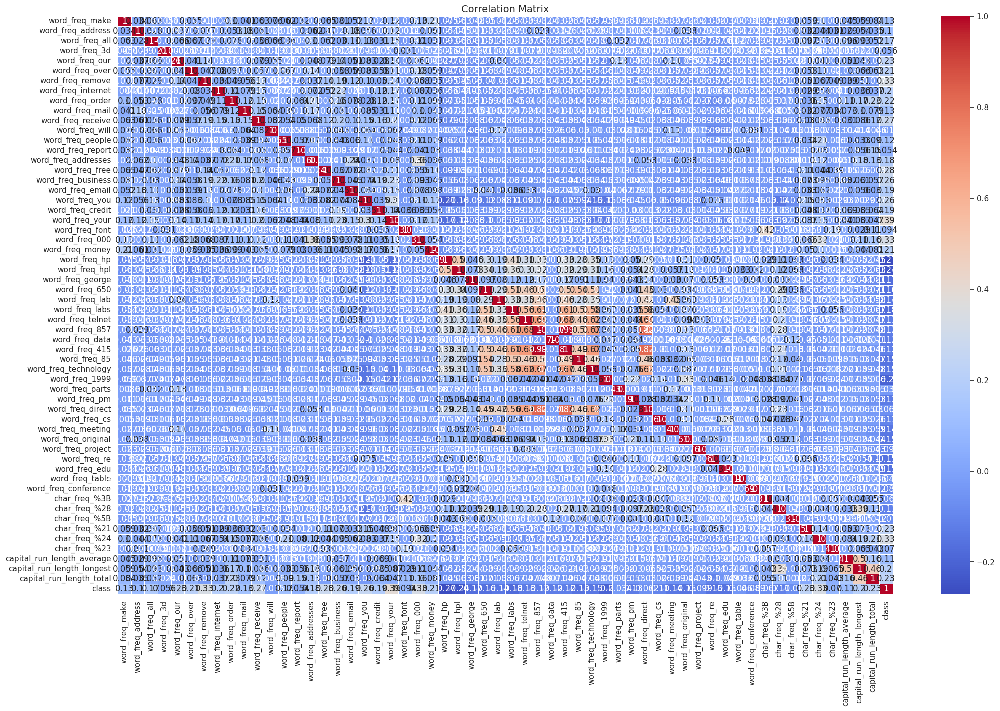

In [ ]:
plt.figure(figsize=(25, 15))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

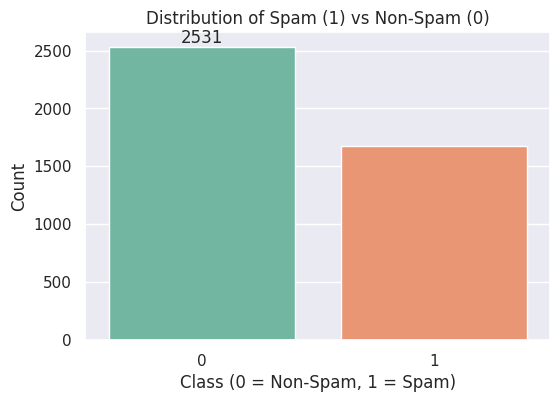

--- Basic Statistical Summary (Top 10 features) ---


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail
count,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000
mean,0.104366,0.112656,0.291473,0.063078,0.325321,0.096656,0.117475,0.108000,0.091860,0.248420
std,0.300005,0.454260,0.515719,1.352487,0.687805,0.276030,0.397284,0.410282,0.282144,0.656638
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.440000,0.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.190000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000



--- Top 5 Most Skewed Features ---
char_freq_%23                 31.500180
capital_run_length_longest    31.205495
word_freq_3d                  27.209539
word_freq_parts               27.078694
capital_run_length_average    22.760655
dtype: float64


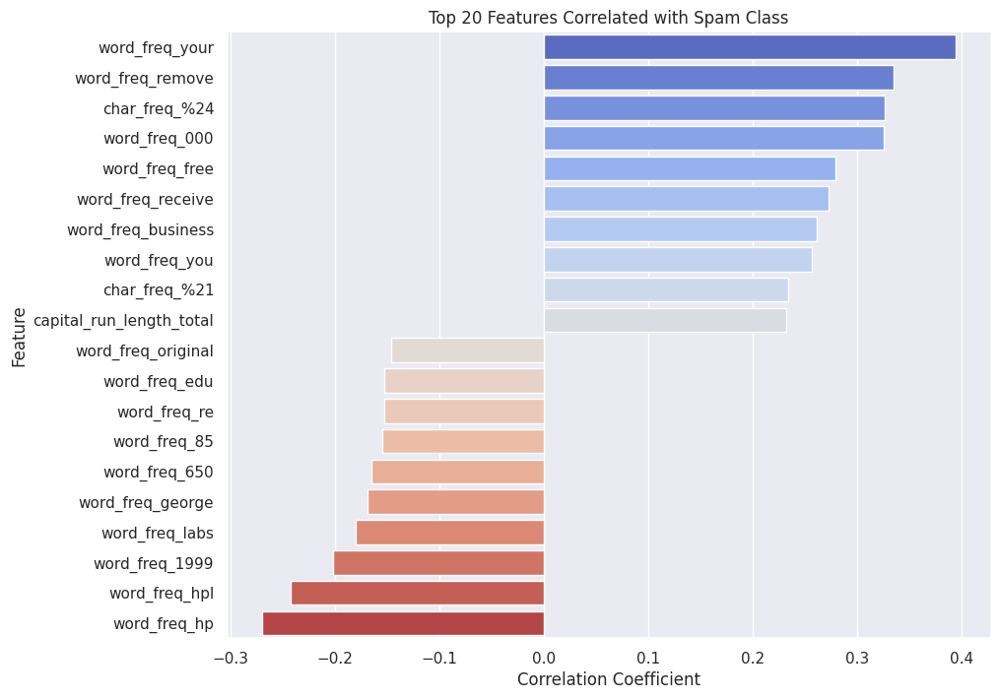

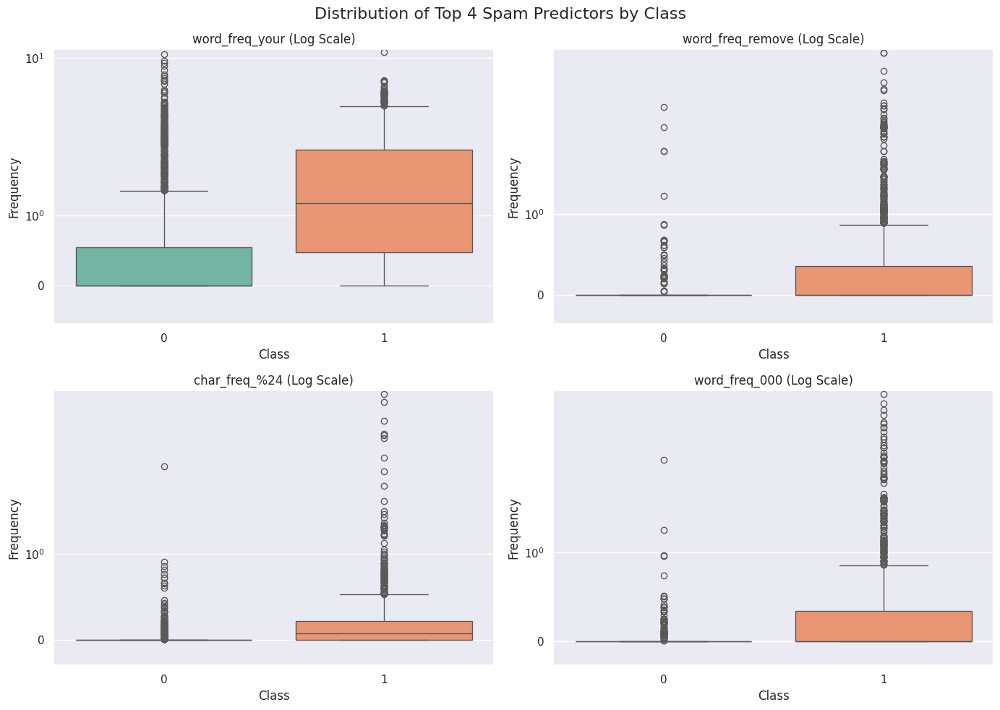

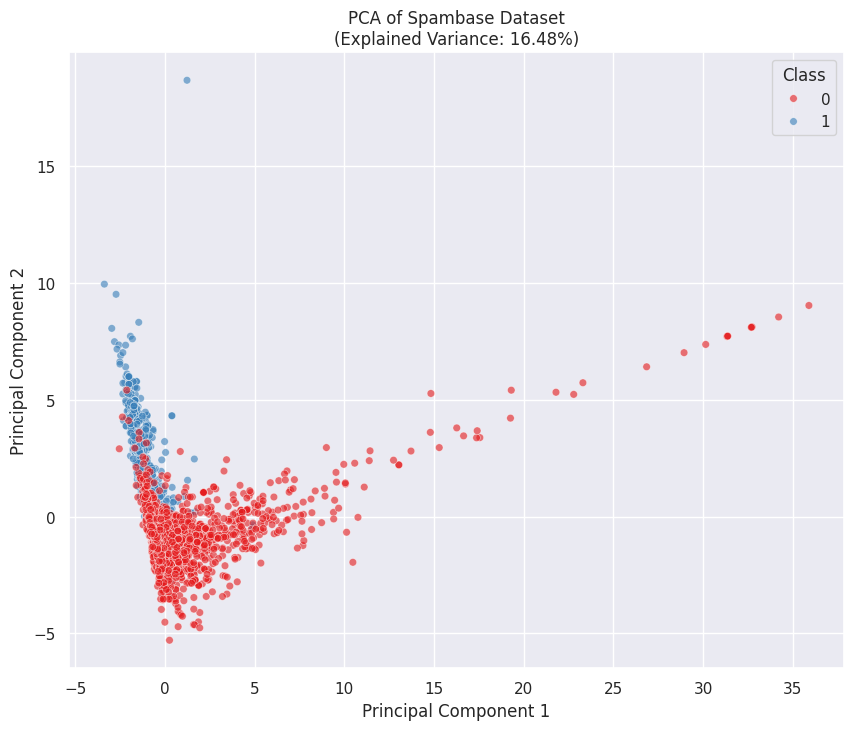

In [ ]:
# 1. Target Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='class', palette='Set2')
plt.title('Distribution of Spam (1) vs Non-Spam (0)')
plt.xlabel('Class (0 = Non-Spam, 1 = Spam)')
plt.ylabel('Count')
ax.bar_label(ax.containers[0])
plt.show()

# 2. Statistical Summary & Skewness Check
print("--- Basic Statistical Summary (Top 10 features) ---")
display(df.iloc[:, :10].describe())

# Check skewness of features (excluding the target 'class')
skewness = df.drop('class', axis=1).skew().sort_values(ascending=False)
print("\n--- Top 5 Most Skewed Features ---")
print(skewness.head(5))

# 3. Correlation with Target Variable
plt.figure(figsize=(10, 8))
# Calculating correlations with 'class' and sort them
corr_with_target = df.corr()['class'].drop('class').sort_values(ascending=False)

# Getting the top 10 positive and top 10 negative correlated features
top_features = pd.concat([corr_with_target.head(10), corr_with_target.tail(10)])

sns.barplot(x=top_features.values, y=top_features.index, palette='coolwarm')
plt.title('Top 20 Features Correlated with Spam Class')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.show()

# 4. Feature Distributions (Spam vs Non-Spam)
top_4_spam_features = corr_with_target.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Top 4 Spam Predictors by Class', fontsize=16)

for i, feature in enumerate(top_4_spam_features):
    row, col = divmod(i, 2)
    # Usinging log scale for better visibility due to heavy skewness
    sns.boxplot(data=df, x='class', y=feature, ax=axes[row, col], palette='Set2')
    axes[row, col].set_yscale('symlog')
    axes[row, col].set_title(f'{feature} (Log Scale)')
    axes[row, col].set_xlabel('Class')
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 5. Dimensionality Reduction (PCA) to visualize overall separability
# Separating features and target
X = df.drop('class', axis=1)
y = df['class']

# Standardizing the features before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Creating a DataFrame for PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['class'] = y.values

# Plotting PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='class',
    data=pca_df,
    palette='Set1',
    alpha=0.6,
    s=30
)
plt.title(f'PCA of Spambase Dataset\n(Explained Variance: {sum(pca.explained_variance_ratio_)*100:.2f}%)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class')
plt.show()

# Feature Engineering & Machine Learning

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       506
           1       0.93      0.90      0.92       336

    accuracy                           0.93       842
   macro avg       0.93      0.93      0.93       842
weighted avg       0.93      0.93      0.93       842


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       506
           1       0.94      0.93      0.93       336

    accuracy                           0.95       842
   macro avg       0.94      0.94      0.94       842
weighted avg       0.95      0.95      0.95       842



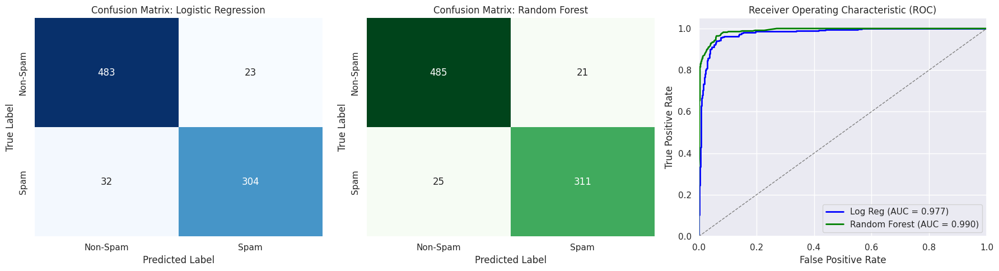

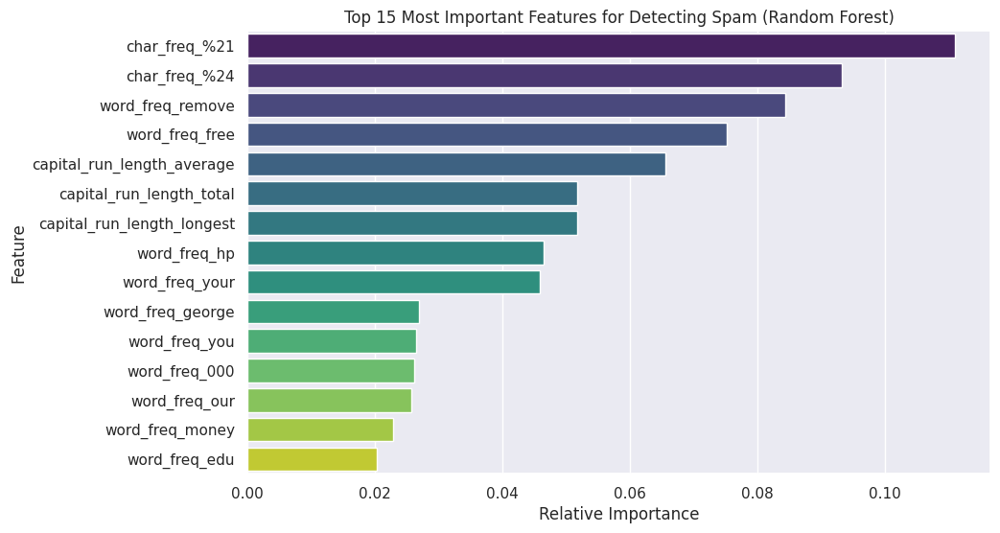

In [ ]:
# 1. Feature Engineering: Train/Test Split & Scaling
# Separating features and target
X = df.drop('class', axis=1)
y = df['class']

# Splitting the data (80% training, 20% testing)
# stratify ensures the spam/non-spam ratio remains the same in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features (Mean=0, Variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Only transform the test set to prevent data leakage
X_test_scaled = scaler.transform(X_test)

# 2. Model Training
# Initializing the models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the models
log_reg.fit(X_train_scaled, y_train)
rf_clf.fit(X_train_scaled, y_train)

# Getting predictions and probability scores (for ROC curves)
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = rf_clf.predict(X_test_scaled)
y_prob_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

# Printing Text Reports
print("--- Logistic Regression Performance ---")
print(classification_report(y_test, y_pred_lr))
print("\n--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf))

# 3. Visualizations

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Visualization A: Confusion Matrix (Logistic Regression)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Non-Spam', 'Spam'])
axes[0].set_yticklabels(['Non-Spam', 'Spam'])

# Visualization B: Confusion Matrix (Random Forest)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix: Random Forest')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(['Non-Spam', 'Spam'])
axes[1].set_yticklabels(['Non-Spam', 'Spam'])

# Visualization C: ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[2].plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Log Reg (AUC = {roc_auc_lr:.3f})')
axes[2].plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Receiver Operating Characteristic (ROC)')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

# 4. Feature Importance Visualization (Random Forest)
# Extract feature importances from the Random Forest model
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15 # Show top 15 features

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:top_n], y=X.columns[indices][:top_n], palette='viridis')
plt.title(f'Top {top_n} Most Important Features for Detecting Spam (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

# Thank you